In [2]:
from pandas import read_csv
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [3]:

dataset = read_csv("Bank_Personal_Loan_Modelling.csv")

In [4]:
# shape
print(dataset.shape)

(5000, 14)


In [5]:


# head
print(dataset.head(20))

    ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0    1   25           1      49     91107       4    1.6          1         0   
1    2   45          19      34     90089       3    1.5          1         0   
2    3   39          15      11     94720       1    1.0          1         0   
3    4   35           9     100     94112       1    2.7          2         0   
4    5   35           8      45     91330       4    1.0          2         0   
5    6   37          13      29     92121       4    0.4          2       155   
6    7   53          27      72     91711       2    1.5          2         0   
7    8   50          24      22     93943       1    0.3          3         0   
8    9   35          10      81     90089       3    0.6          2       104   
9   10   34           9     180     93023       1    8.9          3         0   
10  11   65          39     105     94710       4    2.4          3         0   
11  12   29           5     

In [6]:
print(dataset.describe())

                ID          Age   Experience       Income      ZIP Code  \
count  5000.000000  5000.000000  5000.000000  5000.000000   5000.000000   
mean   2500.500000    45.338400    20.104600    73.774200  93152.503000   
std    1443.520003    11.463166    11.467954    46.033729   2121.852197   
min       1.000000    23.000000    -3.000000     8.000000   9307.000000   
25%    1250.750000    35.000000    10.000000    39.000000  91911.000000   
50%    2500.500000    45.000000    20.000000    64.000000  93437.000000   
75%    3750.250000    55.000000    30.000000    98.000000  94608.000000   
max    5000.000000    67.000000    43.000000   224.000000  96651.000000   

            Family        CCAvg    Education     Mortgage  Personal Loan  \
count  5000.000000  5000.000000  5000.000000  5000.000000    5000.000000   
mean      2.396400     1.937938     1.881000    56.498800       0.096000   
std       1.147663     1.747659     0.839869   101.713802       0.294621   
min       1.000000  

In [7]:
print(dataset.groupby('Personal Loan').size())

Personal Loan
0    4520
1     480
dtype: int64


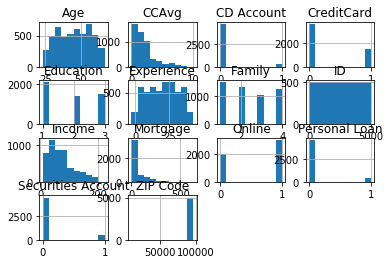

In [9]:

# histograms
dataset.hist()
pyplot.show()

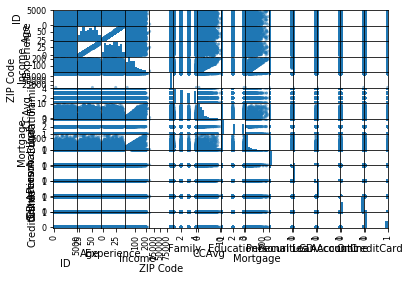

In [11]:
scatter_matrix(dataset)
pyplot.show()

In [15]:

X = dataset.drop(columns=['ID', 'Personal Loan'])
y=dataset['Personal Loan']


X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.30, random_state=1)

In [16]:
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

In [17]:
results = []
names = []
for name, model in models:
	kfold = StratifiedKFold(n_splits=10, random_state=1)
	cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
	results.append(cv_results)
	names.append(name)
	print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.907710 (0.008803)
LDA: 0.940286 (0.008325)
KNN: 0.903723 (0.013222)
CART: 0.986000 (0.006815)
NB: 0.894864 (0.012591)
SVM: 0.905429 (0.000769)


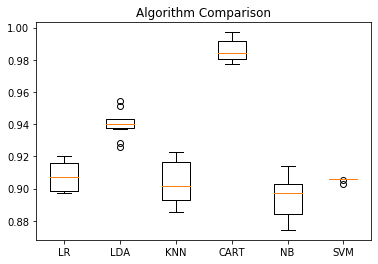

In [18]:
# Compare Algorithms
pyplot.boxplot(results, labels=names)
pyplot.title('Algorithm Comparison')
pyplot.show()

In [19]:
model = SVC(gamma='auto')
model.fit(X_train, Y_train)
predictions = model.predict(X_validation)

In [20]:
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.9006666666666666
[[1351    0]
 [ 149    0]]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1351
           1       0.00      0.00      0.00       149

    accuracy                           0.90      1500
   macro avg       0.45      0.50      0.47      1500
weighted avg       0.81      0.90      0.85      1500



/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
